# Metacatalog NED-LVS cross-match

Cross-match the OVRO-LWA metacatalog against the latest [NED Local Volume Sample](https://ned.ipac.caltech.edu/NED::LVS/) (Cook et al. 2023).

Choose a metacatalog subset in the config cell before cross-matching. Matching uses **centroid position uncertainty** (`E_RA`/`E_DEC` when present, else `cluster_jitter_rms_deg`) scaled by `POSITION_SIGMA_SCALE` (default 3σ), not beam width. NED-LVS galaxies above `MAX_REDSHIFT` are excluded.

**Primary metric:** fraction of selected metacatalog rows with a NED-LVS galaxy within the scaled centroid error.

**SFR–radio plot:** unique matches only (`n_nedlvs == 1`); converts highest-frequency LWA flux to `nu*L_nu` vs NED-LVS SFR.

**Size comparison:** unique matches only; metacatalog `Maj` (FWHM, converted to arcsec) vs NED-LVS projected diameter (`Diam_arcsec`).

**82 MHz flux ECDF:** cumulative fraction of sources vs `Total_flux_82MHz` when that column is present (loads the `_subband` metacatalog sibling if needed).

**Run cells in order.**

In [1]:
from pathlib import Path

import pandas as pd

from lwa_catalog import CatalogLayout, read_metacatalog, resolve_metacatalog_path
from lwa_catalog.analyze import (
    NedlvsMatchConfig,
    build_sfr_radio_luminosity_table,
    filter_or_hesl,
    load_nedlvs_catalog,
    match_catalog_to_nedlvs,
    select_metacatalog,
    select_unique_nedlvs_matches,
    summarize_nedlvs_match,
)
from lwa_catalog.constants import (
    NEDLVS_DEFAULT_MAX_REDSHIFT,
    NEDLVS_DEFAULT_PATH,
)

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75")
NEDLVS_PATH = NEDLVS_DEFAULT_PATH
APPLY_OR_HESL_FILTER = True  # filter_or_hesl after load; needs quality_flag column

# Metacatalog subset before cross-match:
#   "full" | "blue" | "quality_all_clear" | "query"
METACATALOG_SELECTION = "blue"
METACATALOG_QUERY = "Peak_flux > 1.0"  # used only when METACATALOG_SELECTION == "query"

# Cross-match: sep <= POSITION_SIGMA_SCALE * sqrt(sigma_meta^2 + sigma_ned^2)
POSITION_SIGMA_SCALE = 3.0
MAX_REDSHIFT = 0.0223

layout = CatalogLayout(CATALOG_DIR)
config = NedlvsMatchConfig(
    catalog_path=NEDLVS_PATH,
    position_sigma_scale=POSITION_SIGMA_SCALE,
    max_redshift=MAX_REDSHIFT,
)

print("CATALOG_DIR =", layout.root.resolve())
print("metacatalog path =", resolve_metacatalog_path(layout))
print("APPLY_OR_HESL_FILTER =", APPLY_OR_HESL_FILTER)
print("NEDLVS_PATH =", Path(NEDLVS_PATH).resolve())
print("METACATALOG_SELECTION =", METACATALOG_SELECTION)
print("POSITION_SIGMA_SCALE =", POSITION_SIGMA_SCALE)
print("MAX_REDSHIFT =", MAX_REDSHIFT)

CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75
metacatalog path = /fast/claw/metacatalog_coaddR-0.75/metacatalog_quality.parquet
APPLY_OR_HESL_FILTER = True
NEDLVS_PATH = /fast/claw/NEDLVS_current.fits
METACATALOG_SELECTION = blue
POSITION_SIGMA_SCALE = 3.0
MAX_REDSHIFT = 0.0223


## Load and select metacatalog

In [2]:
metacatalog = read_metacatalog(
    layout,
    prefer_quality=True,
    prefer_spectral=True,
    quality_mask=None,
)
if APPLY_OR_HESL_FILTER:
    metacatalog = filter_or_hesl(metacatalog)
selected_meta = select_metacatalog(
    metacatalog,
    selection=METACATALOG_SELECTION,
    layout=layout,
    query=METACATALOG_QUERY,
)

print(f"metacatalog rows: {len(metacatalog)}")
print(f"selected rows ({METACATALOG_SELECTION}): {len(selected_meta)}")
print(f"quality_flag present: {'quality_flag' in metacatalog.columns}")

metacatalog rows: 95938
selected rows (blue): 93560
quality_flag present: True


## Load NED-LVS

Loads ~2.1M rows from the FITS table (takes ~15–30 s on lwacalim09).

In [3]:
nedlvs = load_nedlvs_catalog(NEDLVS_PATH)
print(f"NED-LVS rows: {len(nedlvs):,}")
print(f"rows with Diam: {(nedlvs['Diam_arcsec'] > 0).sum():,}")
nedlvs.head()

NED-LVS rows: 2,103,732
rows with Diam: 1,701,193


,objname,RA,DEC,objtype,z,DistMpc,Mstar,SFR_hybrid,SFR_W4,Diam_arcsec
0,b'WISEA J120155.41+623831.1',180.480897,62.641997,b'G',-0.000509,0.0,NaN,NaN,NaN,NaN
1,b'DESI J252.3925+33.8869',252.392549,33.886965,b'G',-0.000409,0.0,NaN,NaN,NaN,NaN
2,b'WISEA J090812.84+514023.6',137.053538,51.673233,b'IrS',-0.000102,0.0,NaN,NaN,NaN,NaN
3,b'DESI J194.2665+32.1772',194.266570,32.177269,b'G',-0.000922,0.0,NaN,NaN,NaN,NaN
4,b'SDSS J120327.61-015758.7',180.865007,-1.966329,b'G',-0.000043,0.0,NaN,NaN,NaN,NaN


## Cross-match against NED-LVS

In [4]:
result = match_catalog_to_nedlvs(selected_meta, nedlvs=nedlvs, config=config)
print(summarize_nedlvs_match(result))

LWA target rows:                 93560
NED-LVS footprint (Dec box):     72229
Meta matched (>=1 NED-LVS):       1570
Meta with NED-LVS host:         0.017
Meta unique match (n=1):          1221
Meta unique fraction:           0.013
NED-LVS matched (>=1 meta):       2507
NED-LVS recovery:               0.035
NED-LVS over-split (n_meta>1):      10
Meta multi-NED-LVS (n>1):          349
Max NED-LVS hits per meta:         134

Warnings:
  - redshift filter z <= 0.0223: 1851609 NED-LVS rows removed from footprint


## Diagnostics

In [5]:
meta_flags = result.meta_flags
nedlvs_flags = result.nedlvs_flags

print("NED-LVS hits per meta (value_counts):")
display(meta_flags["n_nedlvs"].value_counts().sort_index())

print("\nMeta rows with no NED-LVS host (first 20):")
display(meta_flags.loc[~meta_flags["matched"]].head(20))

oversplit_cols = [
    c
    for c in [
        "nedlvs_pos",
        "RA",
        "DEC",
        "objname",
        "DistMpc",
        "n_meta",
        "meta_ids",
        "oversplit",
    ]
    if c in nedlvs_flags.columns
]
print("\nOver-split NED-LVS rows (multiple meta matches, first 20):")
display(nedlvs_flags.loc[nedlvs_flags["oversplit"], oversplit_cols].head(20))

NED-LVS hits per meta (value_counts):


n_nedlvs
0      91990
1       1221
2        226
3         60
4         29
5         10
6          3
7          6
8          2
9          2
10         2
11         1
13         1
14         1
19         1
20         1
37         1
45         1
91         1
134        1
Name: count, dtype: int64


Meta rows with no NED-LVS host (first 20):


,meta_id,RA,DEC,centroid_sigma_deg,n_nedlvs,nedlvs_positions,matched
0,15,287.779034,9.110626,0.033744,0,[],False
1,38,284.842552,12.986763,0.031864,0,[],False
2,43,285.702609,-23.499407,0.040147,0,[],False
3,48,73.338506,31.493175,0.050156,0,[],False
4,54,5.088203,15.692305,0.050256,0,[],False
5,59,317.078441,49.623061,0.032200,0,[],False
6,63,271.264055,11.020875,0.049961,0,[],False
7,64,71.562029,39.759383,0.033117,0,[],False
8,68,269.657976,-16.315020,0.046391,0,[],False
9,69,276.225902,-32.716981,0.033943,0,[],False



Over-split NED-LVS rows (multiple meta matches, first 20):


,nedlvs_pos,RA,DEC,objname,DistMpc,n_meta,meta_ids,oversplit
6564,6564,63.027446,70.772528,b'WISEA J041206.58+704621.0',16.702084,2,"[16584, 86371]",True
12011,12011,140.393207,-12.723106,b'WISEA J092134.36-124323.1',26.998926,2,"[62650, 87687]",True
14542,14542,73.150068,52.212853,b'WISEA J045236.01+521246.2',32.444546,2,"[53097, 92775]",True
15880,15880,34.665278,-36.531092,b'ESO 355- G 005',35.483097,2,"[250, 54235]",True
26634,26634,112.473561,40.095464,b'WISEA J072953.65+400543.6',51.310902,2,"[14664, 90055]",True
37693,37693,47.386848,53.437707,b'WISEA J030932.84+532615.7',66.547531,2,"[4768, 66034]",True
38462,38462,27.432386,35.785653,b'NGC 0679',67.388123,2,"[11834, 79372]",True
42197,42197,73.100763,52.186573,b'WISEA J045224.18+521111.6',71.135895,2,"[53097, 92775]",True
55411,55411,177.261128,18.853263,b'WISEA J114902.67+185111.7',84.100761,2,"[15777, 81990]",True
63699,63699,134.569390,16.883185,b'WISEA J085816.65+165259.4',91.353584,2,"[2294, 57365]",True


## NED-LVS recovery vs distance (unique matches only)

For each `DistMpc` threshold, recovery is the fraction of bijective NED-LVS matches (exactly one galaxy per meta row, and one meta row per galaxy) at or closer than that distance.

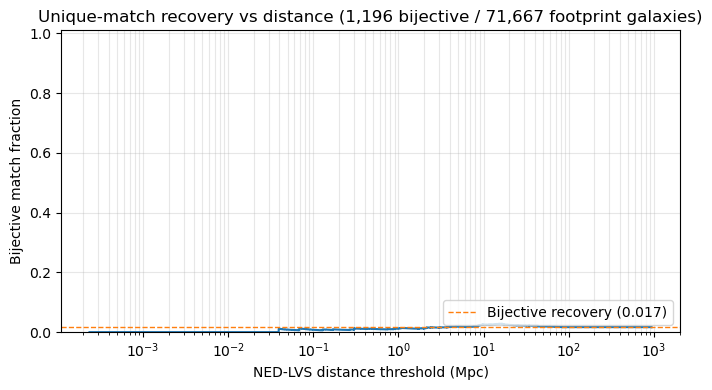

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

from lwa_catalog.analyze import select_bijective_nedlvs_flags

bijective_ned = select_bijective_nedlvs_flags(result.meta_flags, result.nedlvs_flags)
bijective_pos = set(bijective_ned["nedlvs_pos"].astype(int).tolist())

footprint_dist = pd.to_numeric(result.nedlvs_footprint["DistMpc"], errors="coerce")
ok = np.isfinite(footprint_dist.to_numpy(dtype=float)) & (footprint_dist > 0)
dist_all = footprint_dist.loc[ok].to_numpy()
matched = np.array(
    [1 if pos in bijective_pos else 0 for pos in footprint_dist.loc[ok].index],
    dtype=int,
)
order = np.argsort(dist_all)
dist_all = dist_all[order]
matched = matched[order]

suffix_matched = np.cumsum(matched)
suffix_total = np.arange(1, len(dist_all) + 1, dtype=float)
recovery = suffix_matched / suffix_total
overall = float(suffix_matched[-1] / suffix_total[-1]) if len(dist_all) else float("nan")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dist_all, recovery, drawstyle="steps-post")
ax.axhline(
    overall,
    color="C1",
    ls="--",
    lw=1,
    label=f"Bijective recovery ({overall:.3f})",
)
ax.set_xscale("log")
ax.set_xlabel("NED-LVS distance threshold (Mpc)")
ax.set_ylabel("Bijective match fraction")
ax.set_ylim(0, 1.01)
ax.set_title(
    f"Unique-match recovery vs distance ({int(suffix_matched[-1]):,} bijective / "
    f"{len(dist_all):,} footprint galaxies)"
)
ax.legend(loc="lower right")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## SFR–radio luminosity relation (unique matches only)

Uses only meta rows with exactly one NED-LVS association (`n_nedlvs == 1`). For each pair with NED-LVS SFR and redshift, the highest-frequency positive `Peak_flux_{band}` is converted to `nu*L_nu` and plotted versus SFR.

In [7]:
unique_meta = select_unique_nedlvs_matches(result.meta_flags)
print(
    f"unique meta matches: {len(unique_meta):,} / {len(result.meta_flags):,} matched rows"
)

sfr_radio = build_sfr_radio_luminosity_table(
    selected_meta,
    result.nedlvs_footprint,
    result.meta_flags,
    unique_only=True,
)
print(f"unique pairs with SFR + radio luminosity: {len(sfr_radio)}")
display(sfr_radio.head())

unique meta matches: 1,221 / 93,560 matched rows
unique pairs with SFR + radio luminosity: 924


,meta_id,objname,z,SFR,SFR_column,radio_band,radio_freq_hz,Peak_flux_jy,L_nu_erg_s_hz,nuL_nu_erg_s
0,285,b'WISEA J032636.84+415632.4',0.019899,0.102445,SFR_W4,Blue,7.395688e+07,2.048774,1.963813e+31,1.452375e+39
1,318,b'NGC 4234',0.006719,0.851076,SFR_hybrid,Blue,7.395688e+07,5.771580,6.184548e+30,4.573899e+38
2,334,b'WISEA J052620.44+513723.6',0.020814,0.196927,SFR_W4,Blue,7.395688e+07,13.543265,1.422228e+32,1.051836e+40
3,384,b'NGC 6140',0.003029,0.123354,SFR_hybrid,Blue,7.395688e+07,6.775067,1.466942e+30,1.084904e+38
4,415,b'KUG 2338+043',0.020578,0.127994,SFR_hybrid,Blue,7.395688e+07,3.115665,3.196977e+31,2.364385e+39


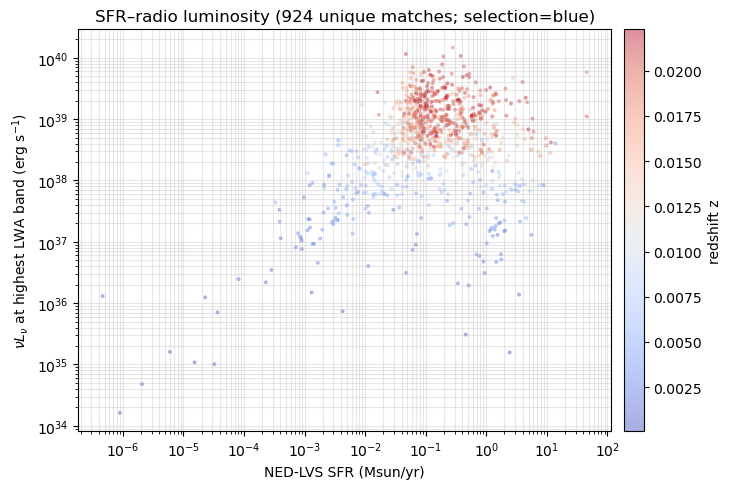

In [8]:
if sfr_radio.empty:
    print("No SFR–radio pairs to plot.")
else:
    fig, ax = plt.subplots(figsize=(7.5, 5))
    sc = ax.scatter(
        sfr_radio["SFR"],
        sfr_radio["nuL_nu_erg_s"],
        c=sfr_radio["z"],
        cmap="coolwarm",
        s=8,
        alpha=0.45,
        edgecolors="none",
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("redshift z")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("NED-LVS SFR (Msun/yr)")
    ax.set_ylabel(r"$\nu L_\nu$ at highest LWA band (erg s$^{-1}$)")
    ax.set_title(
        f"SFR–radio luminosity ({len(sfr_radio):,} unique matches; "
        f"selection={METACATALOG_SELECTION})"
    )
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Metacatalog Maj vs NED-LVS projected size (unique matches only)

Compares PyBDSF major-axis FWHM (`Maj`, degrees → arcsec) with the NED-LVS galaxy projected diameter (`Diam_arcsec`). Only bijective meta↔NED pairs are shown.

unique pairs with Maj + NED-LVS Diam: 963


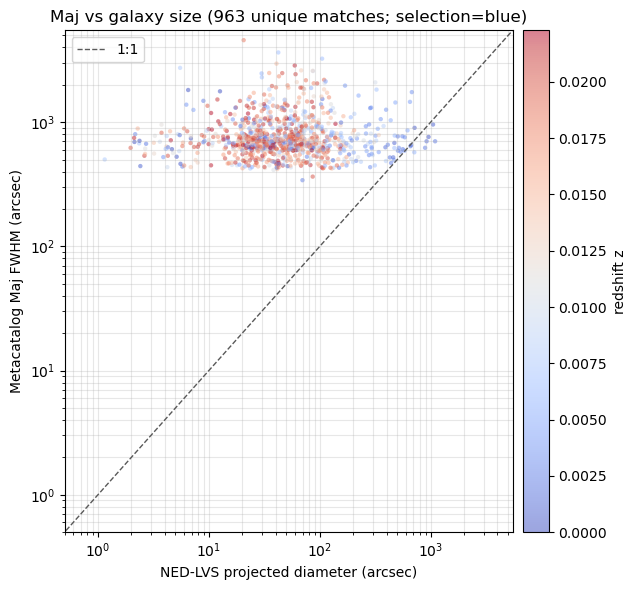

In [9]:
unique_flags = select_unique_nedlvs_matches(result.meta_flags)
meta_by_id = selected_meta.set_index("meta_id", drop=False)

size_records: list[dict] = []
for _, flag in unique_flags.iterrows():
    if not bool(flag.get("matched", False)):
        continue
    positions = flag.get("nedlvs_positions", [])
    if len(positions) != 1:
        continue

    meta_id = flag["meta_id"]
    if meta_id not in meta_by_id.index:
        continue
    meta_row = meta_by_id.loc[meta_id]
    if isinstance(meta_row, pd.DataFrame):
        meta_row = meta_row.iloc[0]

    maj_deg = pd.to_numeric(meta_row.get("Maj"), errors="coerce")
    ned_row = result.nedlvs_footprint.iloc[int(positions[0])]
    diam_arcsec = pd.to_numeric(ned_row.get("Diam_arcsec"), errors="coerce")
    if not (
        np.isfinite(maj_deg)
        and float(maj_deg) > 0.0
        and np.isfinite(diam_arcsec)
        and float(diam_arcsec) > 0.0
    ):
        continue

    size_records.append(
        {
            "meta_id": meta_id,
            "Maj_arcsec": float(maj_deg) * 3600.0,
            "Diam_arcsec": float(diam_arcsec),
            "z": pd.to_numeric(ned_row.get("z"), errors="coerce"),
        }
    )

size_pairs = pd.DataFrame.from_records(size_records)
print(f"unique pairs with Maj + NED-LVS Diam: {len(size_pairs):,}")

if size_pairs.empty:
    print("No size pairs to plot.")
else:
    lim = np.nanmax(
        [size_pairs["Maj_arcsec"].max(), size_pairs["Diam_arcsec"].max()]
    )
    lim = max(float(lim) * 1.2, 1.0)

    fig, ax = plt.subplots(figsize=(6.5, 6))
    sc = ax.scatter(
        size_pairs["Diam_arcsec"],
        size_pairs["Maj_arcsec"],
        c=size_pairs["z"],
        cmap="coolwarm",
        s=10,
        alpha=0.5,
        edgecolors="none",
    )
    ax.plot([0.0, lim], [0.0, lim], color="0.35", ls="--", lw=1, label="1:1")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(0.5, lim)
    ax.set_ylim(0.5, lim)
    ax.set_xlabel("NED-LVS projected diameter (arcsec)")
    ax.set_ylabel("Metacatalog Maj FWHM (arcsec)")
    ax.set_title(
        f"Maj vs galaxy size ({len(size_pairs):,} unique matches; "
        f"selection={METACATALOG_SELECTION})"
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label("redshift z")
    ax.legend(loc="upper left")
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Cumulative 82 MHz total flux

Plots the empirical cumulative distribution of positive `Total_flux_82MHz` for the selected metacatalog. RGB coadd catalogs omit per-MHz flux columns; when needed, the sibling `{catalog}_subband` directory is loaded and rows are matched by `meta_id`.

In [1]:
FLUX_82_COL = "Total_flux_82MHz"
flux_source = selected_meta
flux_source_label = f"{METACATALOG_SELECTION} @ {CATALOG_DIR.name}"

if FLUX_82_COL not in flux_source.columns:
    subband_dir = CATALOG_DIR.parent / f"{CATALOG_DIR.name}_subband"
    if subband_dir.is_dir():
        sub_layout = CatalogLayout(subband_dir)
        sub_meta = read_metacatalog(
            sub_layout,
            prefer_quality=True,
            prefer_spectral=True,
            quality_mask=None,
        )
        if APPLY_OR_HESL_FILTER:
            sub_meta = filter_or_hesl(sub_meta)
        if "meta_id" in selected_meta.columns and "meta_id" in sub_meta.columns:
            flux_source = sub_meta.loc[
                sub_meta["meta_id"].isin(selected_meta["meta_id"])
            ].copy()
        else:
            flux_source = select_metacatalog(
                sub_meta,
                selection=METACATALOG_SELECTION,
                layout=sub_layout,
                query=METACATALOG_QUERY,
            )
        flux_source_label = (
            f"{METACATALOG_SELECTION} meta_ids @ {subband_dir.name}"
        )
    else:
        flux_source = None

if flux_source is None or FLUX_82_COL not in flux_source.columns:
    print(f"{FLUX_82_COL} not available for the selected metacatalog.")
else:
    flux = pd.to_numeric(flux_source[FLUX_82_COL], errors="coerce").to_numpy(dtype=float)
    flux = np.sort(flux[np.isfinite(flux) & (flux > 0)])
    n_flux = len(flux)
    print(f"{FLUX_82_COL}: {n_flux:,} positive finite sources ({flux_source_label})")

    if n_flux == 0:
        print("No positive 82 MHz flux values to plot.")
    else:
        cum_frac = (np.arange(1, n_flux + 1, dtype=float) / n_flux)[::-1]

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(flux, cum_frac, drawstyle="steps-post", color="C0")
        ax.set_xscale("log")
        ax.set_xlabel("N(Total_flux > f0 @ 82 MHz (Jy)")
        ax.set_ylabel("Cumulative fraction")
        ax.set_ylim(0, 1.01)
        ax.set_title(f"Cumulative Total_flux ({n_flux:,} sources)")
        ax.legend(loc="lower right")
        ax.grid(True, which="both", alpha=0.3)
        plt.tight_layout()
        plt.show()

NameError: name 'selected_meta' is not defined